# WALMART SALES PREDICTION MODEL 

## Introduction

- Walmart is one of the largest retail chains in the world, and its sales data provides valuable insights into customer behavior, seasonality, and business performance. The primary objective of this analysis is to understand patterns in the sales data and build predictive models to forecast future sales. By leveraging historical data, the analysis aims to:

- Identify key factors influencing sales.

    - Build robust predictive models to improve forecasting accuracy.

    - Provide actionable recommendations to enhance decision-making for inventory management and promotional strategies.

- This notebook guides the reader through the entire process, from data cleaning and exploratory analysis to feature engineering, model training, and insights extraction. The results aim to help Walmart optimize operations and better meet customer demand.

In [1]:
# importing libraries
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

import warnings

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression,Ridge,SGDRegressor,RidgeCV,Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('/kaggle/input/walmart-dataset/Walmart.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


## Data Wrangling

Enhancements: Code Comments for Data Cleaning

Reason for Dropping Columns: Add comments in the code explaining why specific columns were dropped. For instance, "Dropping 'Column X' as it contains more than 50% missing values, which may skew analysis results."

Imputation Explanation: Include remarks like, "Filling missing values in 'Feature Y' with the mean to preserve data consistency without introducing bias."

Data Formatting: Comments such as, "Converting 'Date' column to datetime format to facilitate time-based analysis" can clarify transformation choices.

Removing Outliers: "Filtering out sales values that exceed the 99th percentile to prevent model distortion caused by outliers.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
# Feature Engineering
df['Date'] = pd.to_datetime(df.Date,format='mixed')
df['Year'] = df.Date.dt.year
df['Month'] = df.Date.dt.month
df['Day'] = df.Date.dt.day

In [5]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,2010-05-02,1643690.90,0,42.31,2.572,211.096358,8.106,2010,5,2
1,1,2010-12-02,1641957.44,1,38.51,2.548,211.242170,8.106,2010,12,2
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,2010-05-03,1554806.68,0,46.50,2.625,211.350143,8.106,2010,5,3
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,28
6431,45,2012-05-10,733455.07,0,64.89,3.985,192.170412,8.667,2012,5,10
6432,45,2012-12-10,734464.36,0,54.47,4.000,192.327265,8.667,2012,12,10
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,19


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Day           6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2)
memory usage: 477.7 KB


## Exploratory Data Analysis

- Exploratory Data Analysis (EDA)

    - Sales Trends Over Time

        - Visualize sales trends to understand seasonality and long-term patterns. For example,"Plotting sales over time highlights peak seasons and potential dips in sales."

        - Summarize findings: "Sales are consistently higher during holiday seasons, with notable peaks around Thanksgiving and Christmas."

    - Impact of Holidays on Sales

        - Explore the effect of holidays by comparing sales on holiday weeks versus non-holiday weeks.

        - Findings: "Holiday weeks show a significant increase in sales, emphasizing the importance of promotional strategies during these periods."

- Feature Engineering

    - Holiday Flags: "Added a binary feature to indicate whether a given date corresponds to a major holiday. This helps the model capture sales spikes during holidays."

    - Lagged Variables: "Introduced lagged sales features to incorporate past sales trends into the model, enhancing its ability to predict future values."

    - Rolling Means: "Calculated rolling averages for smoother trend representation and to reduce noise in the data."

In [7]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,2010-05-02,1643690.90,0,42.31,2.572,211.096358,8.106,2010,5,2
1,1,2010-12-02,1641957.44,1,38.51,2.548,211.242170,8.106,2010,12,2
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,2010-05-03,1554806.68,0,46.50,2.625,211.350143,8.106,2010,5,3
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,28
6431,45,2012-05-10,733455.07,0,64.89,3.985,192.170412,8.667,2012,5,10
6432,45,2012-12-10,734464.36,0,54.47,4.000,192.327265,8.667,2012,12,10
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,19


<Axes: xlabel='Weekly_Sales', ylabel='Temperature'>

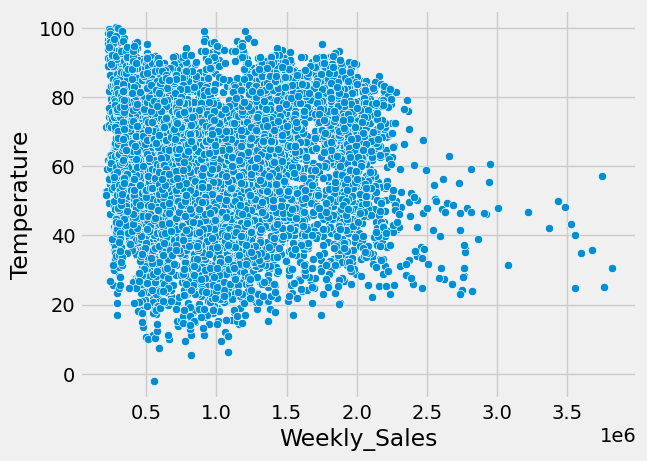

In [8]:
sns.scatterplot(data=df,x='Weekly_Sales',y='Temperature')

<Axes: xlabel='Weekly_Sales', ylabel='Unemployment'>

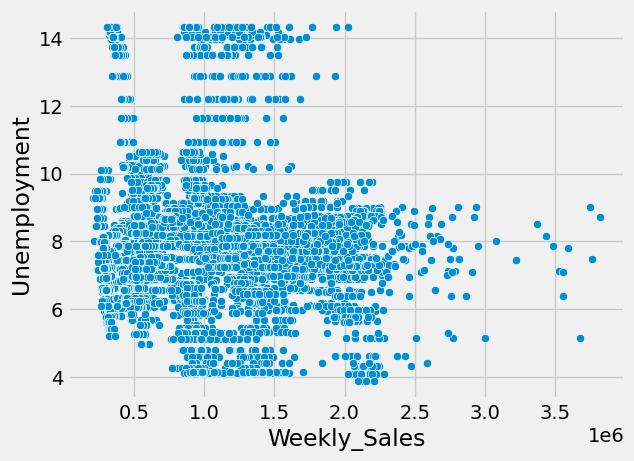

In [9]:
sns.scatterplot(data=df,x='Weekly_Sales',y='Unemployment')

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Weekly_Sales', ylabel='Count'>

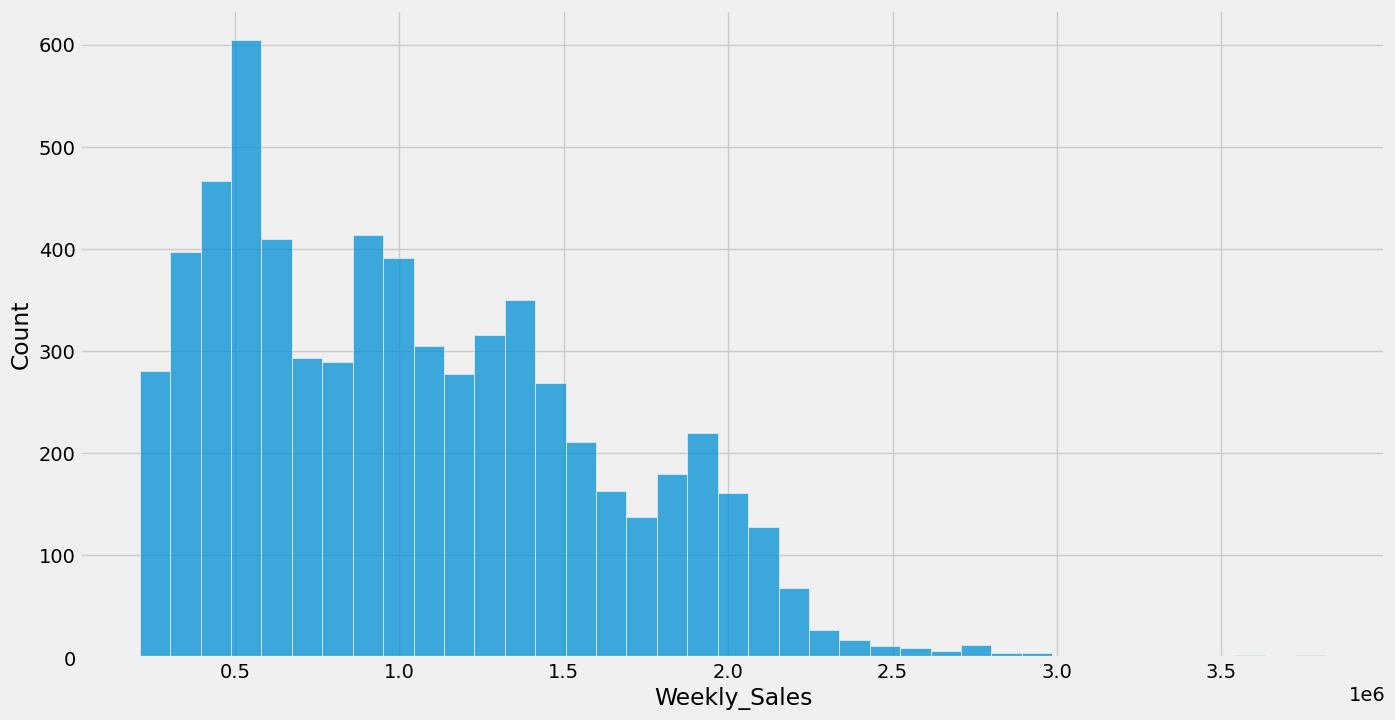

In [10]:
plt.figure(figsize=(15,8))

sns. histplot(data=df,x='Weekly_Sales')

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Weekly_Sales', ylabel='Density'>

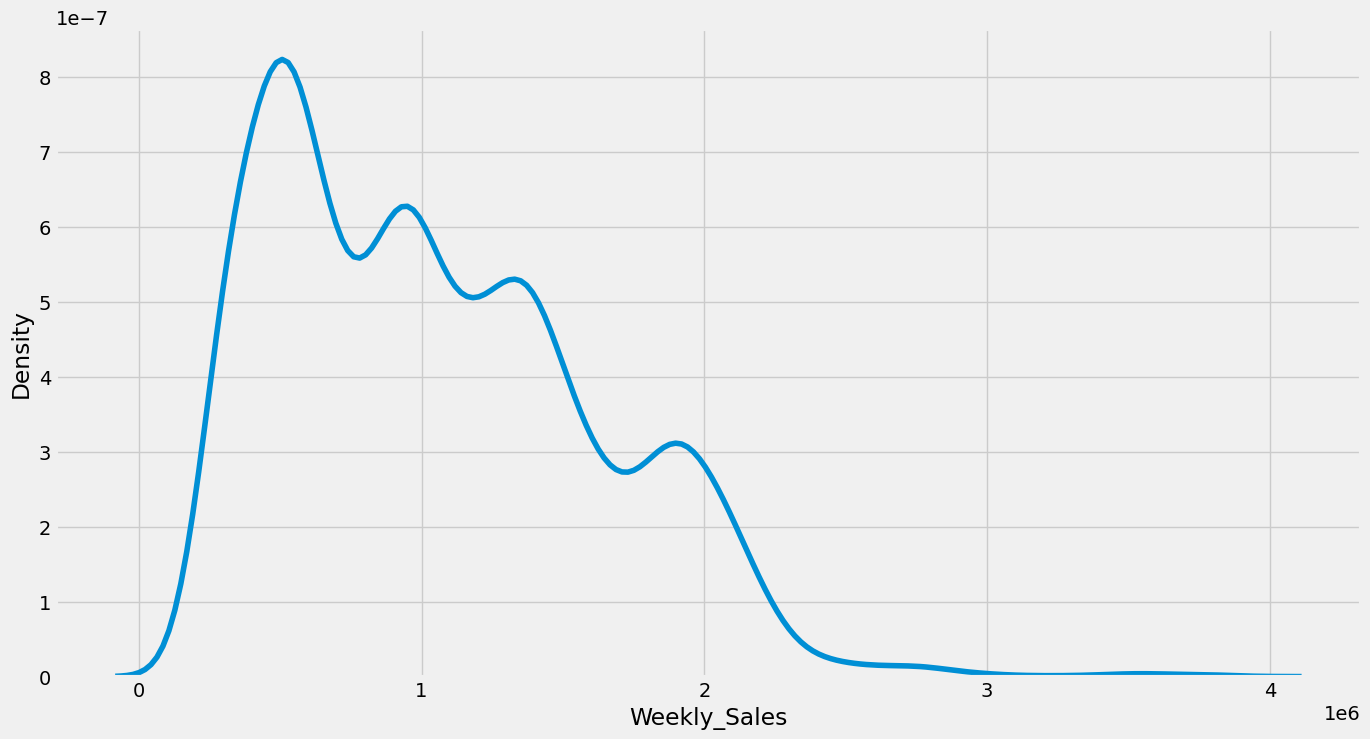

In [11]:
plt.figure(figsize=(15,8))
sns.kdeplot(data=df, x="Weekly_Sales")

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

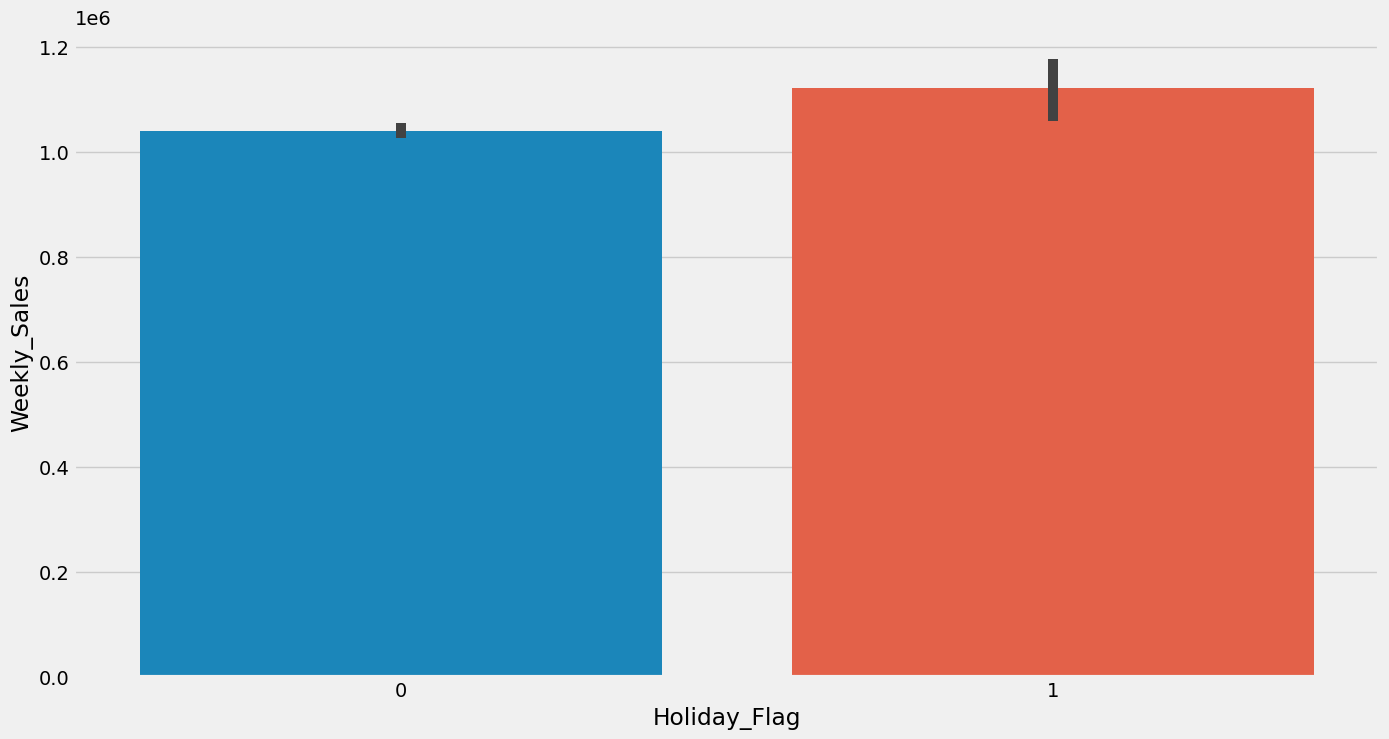

In [12]:
plt.figure(figsize=(15,8))
sns.barplot(data=df,x='Holiday_Flag',y='Weekly_Sales')

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Store', ylabel='Weekly_Sales'>

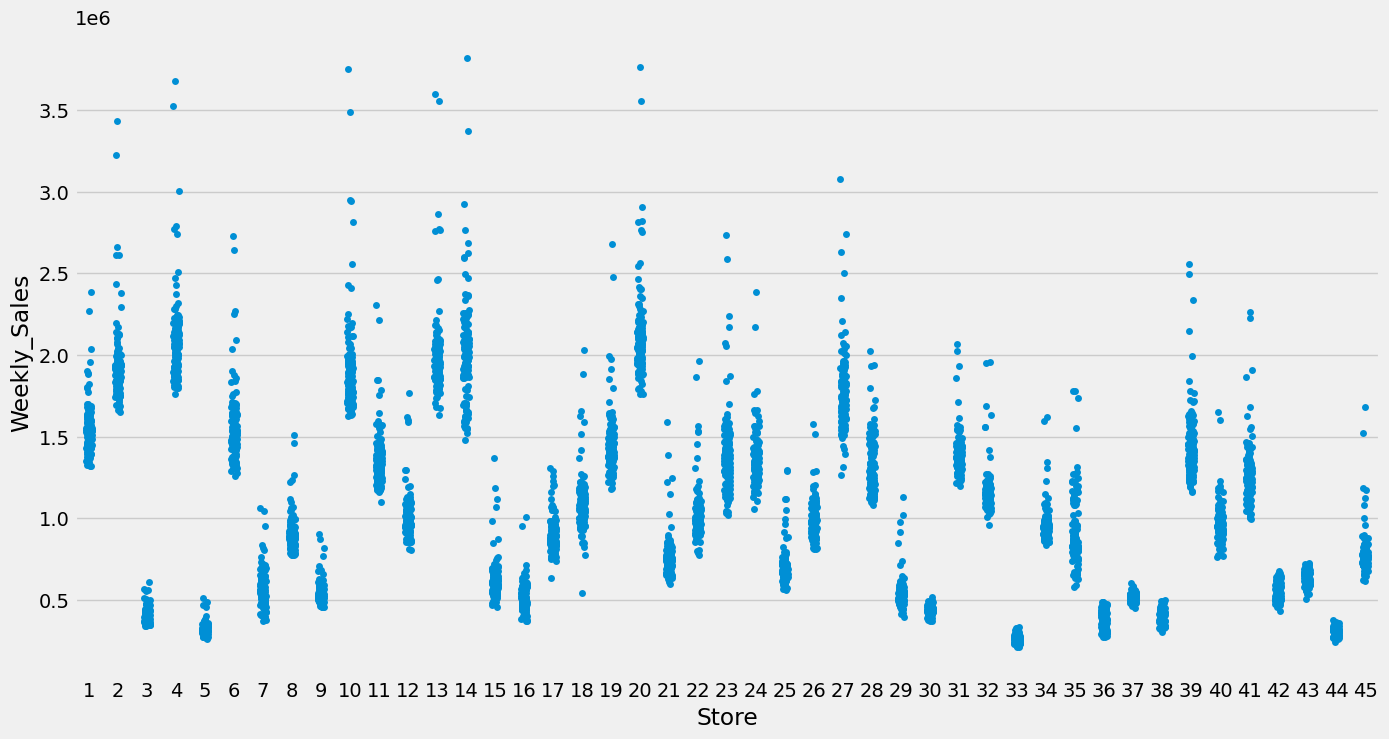

In [13]:
 plt.figure(figsize=(15,8))
sns.stripplot(data=df,x='Store',y='Weekly_Sales')

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

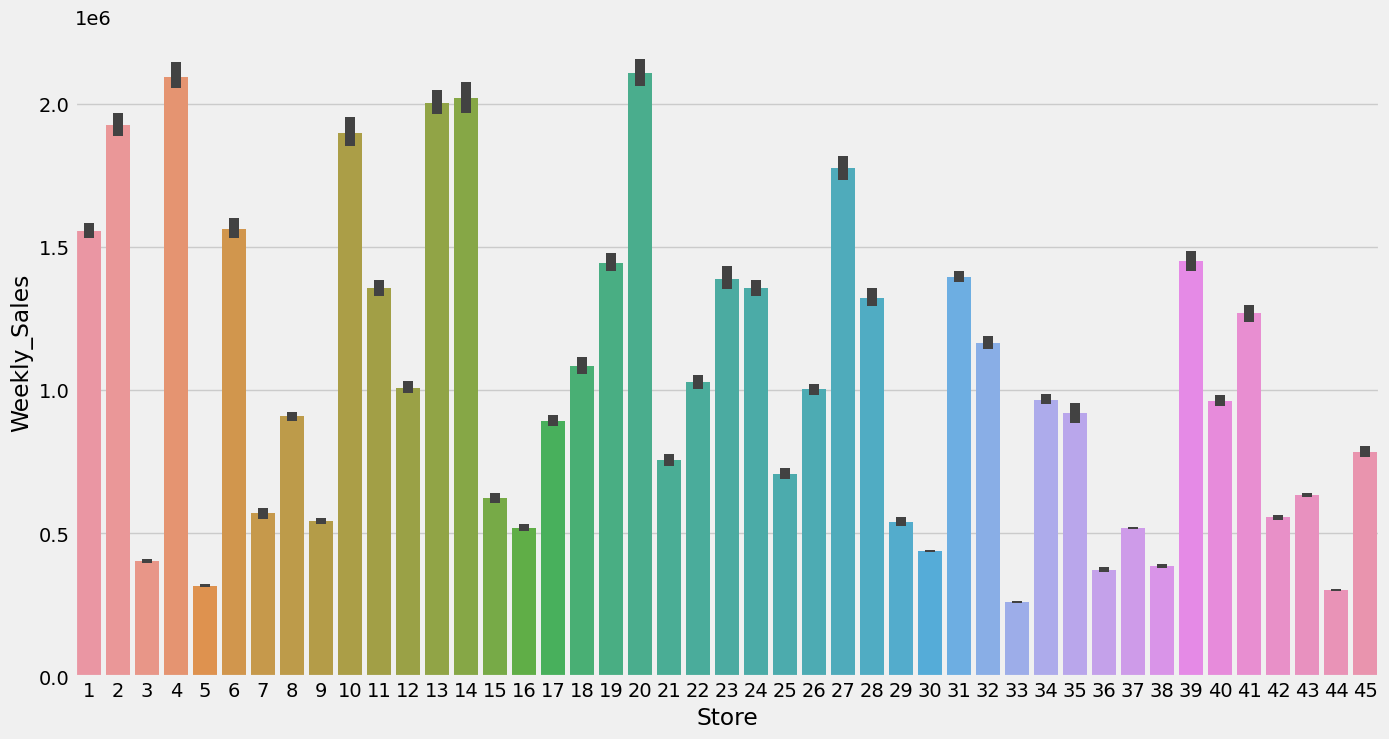

In [14]:
plt.figure(figsize=(15,8))
sns.barplot(data=df,x='Store',y='Weekly_Sales')

In [15]:
df.corr()['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales    1.000000
Month           0.067535
Holiday_Flag    0.036891
Fuel_Price      0.009464
Date            0.004592
Day            -0.014873
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64

## Splitting the dataset into train,test datasets

In [16]:
columns = list(df.columns)
df[columns].nunique()
# no need fro making seperate categorical columns for for the given dataset

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
Year               3
Month             12
Day               31
dtype: int64

In [17]:
# seperating input columns and target columns
X = df.drop(columns=['Weekly_Sales','Date']).copy()
y = df['Weekly_Sales']

numeric_cols = list(X.columns)

In [18]:
# splitting the dataset using train_test_split() from sklearn.model_selection
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state = 36)

In [19]:
X_train

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
4592,33,0,78.47,3.058,126.160226,9.849,2010,5,28
531,4,0,42.09,3.273,130.279226,4.607,2012,1,20
1039,8,0,57.93,2.716,215.273900,6.433,2010,10,29
1608,12,0,71.82,3.013,126.279167,14.313,2010,8,10
4250,30,0,50.79,3.290,219.718864,7.057,2012,1,27
...,...,...,...,...,...,...,...,...,...
1274,9,0,90.23,3.417,225.707044,5.277,2012,3,8
2984,21,0,81.78,3.346,221.441162,6.891,2012,6,22
926,7,0,37.51,3.795,192.836565,8.595,2011,5,27
610,5,0,70.58,2.716,212.464799,6.768,2010,10,29


In [20]:
y_train

4592     279246.33
531     2005097.76
1039     830756.76
1608     918335.68
4250     433037.66
           ...    
1274     533887.54
2984     735870.00
926      457216.87
610      278031.81
4741     911210.81
Name: Weekly_Sales, Length: 4311, dtype: float64

In [21]:
# Imputing Missing values
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train[numeric_cols])

X_train[numeric_cols] = imputer.transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

In [22]:
# Scaling the values to 0 and 1 
scaler = MinMaxScaler()
scaler.fit(X_train[numeric_cols])
X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [23]:
X_train

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
4592,0.727273,0.0,0.770930,0.278772,0.000951,0.572168,0.0,0.363636,0.900000
531,0.068182,0.0,0.386364,0.388747,0.041665,0.069772,1.0,0.000000,0.633333
1039,0.159091,0.0,0.553805,0.103836,0.881793,0.244777,0.0,0.818182,0.933333
1608,0.250000,0.0,0.700634,0.255754,0.002127,1.000000,0.0,0.636364,0.300000
4250,0.659091,0.0,0.478330,0.397442,0.925729,0.304581,1.0,0.000000,0.866667
...,...,...,...,...,...,...,...,...,...
1274,0.181818,0.0,0.895243,0.462404,0.984919,0.133985,1.0,0.181818,0.233333
2984,0.454545,0.0,0.805920,0.426087,0.942753,0.288672,1.0,0.454545,0.700000
926,0.136364,0.0,0.337949,0.655754,0.660011,0.451984,0.5,0.363636,0.866667
610,0.090909,0.0,0.687526,0.103836,0.854026,0.276883,0.0,0.818182,0.933333


## Model building

- Linear Regression

    - Chosen for its simplicity and interpretability. It provides a baseline for comparison with more complex models.

- Random Forest

    - Selected for its ability to handle non-linear relationships and capture interactions between features.

- Visual Comparison of Models

    - Comparison of RMSE values for each model shows that Random Forest outperforms Linear Regression by a significant margin.

### Base model making

In [24]:
def return_mean(inputs):
    return np.full(len(inputs),df.Weekly_Sales.mean())

In [25]:
def score_check(y_true,y_pred):
    print('Root mean squared error of the given model is:',mean_squared_error(y_pred,y_true,squared=False))
    # print('The accuracy score of the model is:',accuracy_score(y_true,y_pred

In [26]:
base_preds = return_mean(X_train)
base_preds

array([1046964.87756177, 1046964.87756177, 1046964.87756177, ...,
       1046964.87756177, 1046964.87756177, 1046964.87756177])

In [27]:
# calculating the percentage of error in the model and the accuracy of the model
score_check(base_preds,y_train)

Root mean squared error of the given model is: 565283.2277681968


This model is having a  loss of around $600000 which is pretty bad for a model 
therefor this model is not acceptable

### Baseline ML Model

In [28]:
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
score_check(y_test,pred)

Root mean squared error of the given model is: 520285.43807922443


In [29]:
def try_model(model):
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    score_check(y_test,preds)

### Linear Models

In [30]:
try_model(LinearRegression())

Root mean squared error of the given model is: 520285.43807922443


In [31]:
try_model(Ridge())

Root mean squared error of the given model is: 520279.8079586221


In [32]:
try_model(RidgeCV()) # very minor changes

Root mean squared error of the given model is: 520279.8079586219


In [33]:
try_model(Lasso())

Root mean squared error of the given model is: 520285.23864933546


In [34]:
try_model(SGDRegressor()) # worst model

Root mean squared error of the given model is: 520090.0952279541


### Tree based models

In [35]:
tree = DecisionTreeRegressor()
try_model(tree)
print(df.columns)
tree.feature_importances_

Root mean squared error of the given model is: 150352.42110736723
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day'],
      dtype='object')


array([7.37418284e-01, 2.06259394e-03, 1.05516075e-02, 4.82728548e-03,
       1.26689240e-01, 6.50375708e-02, 5.93426569e-04, 2.12985254e-02,
       3.15214664e-02])

In [36]:
tree.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

In [37]:
tree.get_depth()

25

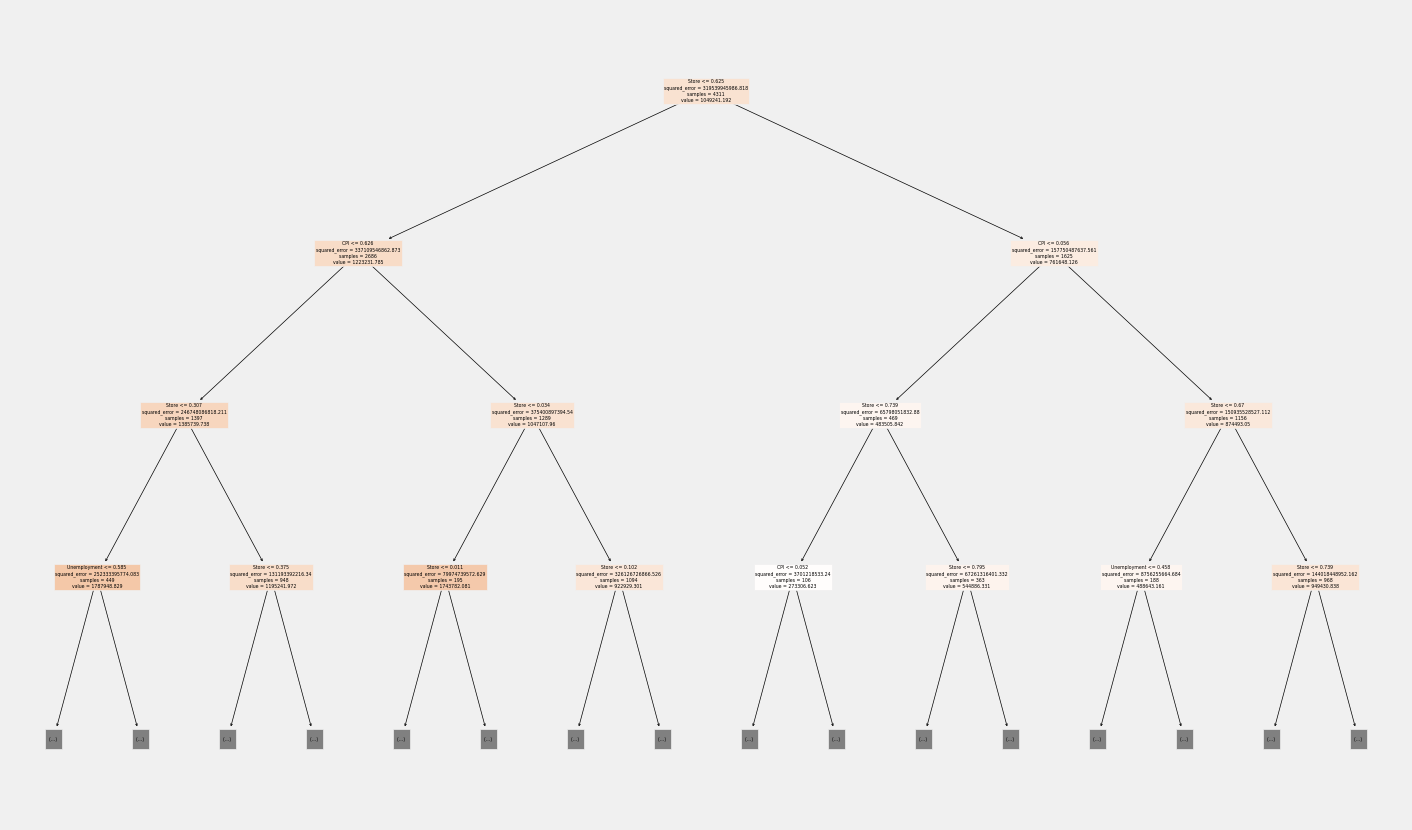

In [38]:
plt.figure(figsize = (16,10))

plot_tree(tree, max_depth=3, filled=True,feature_names = numeric_cols);
plt.show()

In [39]:
# Hyper parameter tuning of the model 
# post prunnig of the model 
hyper_tree = DecisionTreeRegressor(criterion='poisson',max_depth=20,random_state=10,ccp_alpha=4)
try_model(hyper_tree)
print(df.columns)
hyper_tree.feature_importances_

Root mean squared error of the given model is: 151829.08301971504
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day'],
      dtype='object')


array([6.48802588e-01, 1.61888434e-03, 1.09086755e-02, 1.72671099e-02,
       1.89093714e-01, 1.00969009e-01, 5.69394585e-05, 1.37453902e-02,
       1.75376891e-02])

In [40]:
hyper_tree.get_params()

{'ccp_alpha': 4,
 'criterion': 'poisson',
 'max_depth': 20,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 10,
 'splitter': 'best'}

In [41]:
hyper_tree.get_depth()

17

In [42]:
forest_model = RandomForestRegressor(criterion='poisson',random_state=10,max_depth=20)
try_model(forest_model)

Root mean squared error of the given model is: 114925.71267021372


In [43]:
forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'poisson',
 'max_depth': 20,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 10,
 'verbose': 0,
 'warm_start': False}

In [44]:
tree_depths = [estimator.get_depth() for estimator in forest_model.estimators_]
max_depth = max(tree_depths)
mean_depth = int(np.mean(tree_depths))
print(f"Maximum depth of trees in the forest: {max_depth}")

print(f"Mean depth of trees in the forest: {mean_depth}")

# Optional: Display all tree depths
print(f"Depths of individual trees: {tree_depths}")

Maximum depth of trees in the forest: 20
Mean depth of trees in the forest: 20
Depths of individual trees: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]


In [45]:
importance_df = pd.DataFrame({ 
    'feature': numeric_cols, 
    'importance': forest_model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
0,Store,0.674622
4,CPI,0.167675
5,Unemployment,0.098611
7,Month,0.015368
8,Day,0.015202
3,Fuel_Price,0.013446
2,Temperature,0.011321
1,Holiday_Flag,0.002253
6,Year,0.001503


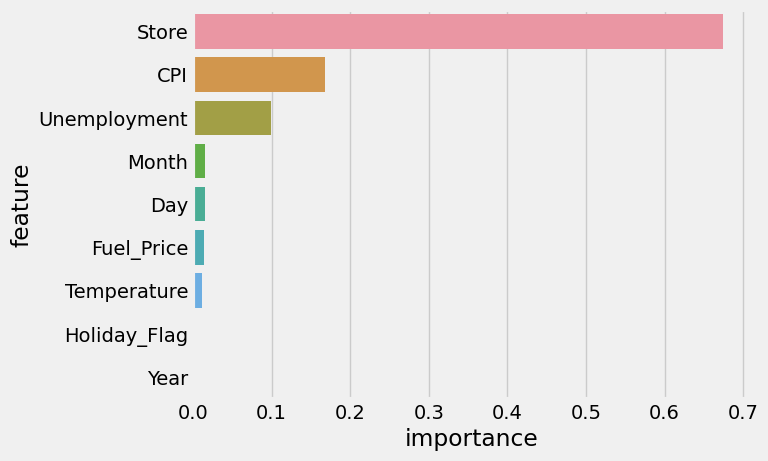

In [46]:
sns.barplot(data=importance_df, x='importance', y='feature');

In [47]:
forest_model.predict(X_test)

array([ 332712.1164    , 1344650.03357859, 1628962.6352    , ...,
        312596.3097    ,  530198.2374    ,  397578.4159    ])

## Result

- Key Insights: "Holiday flags and lagged sales features are the most impactful predictors of sales."

- Business Implications: "Improving inventory management during holiday seasons and leveraging historical data for forecasting can significantly enhance operations."

## Conclusion

This analysis successfully built a predictive model for Walmart sales, providing valuable insights into sales trends and feature importance."

- Suggestions for Future Work:

    - Incorporate external data such as weather or economic indicators to further improve model accuracy.

    - Experiment with advanced models like Gradient Boosting or Neural Networks for potentially better performance.

    - Automate the feature engineering and model evaluation process for scalability.